In [1]:
import numpy as np
from scipy.integrate import quad
import matplotlib.pyplot as plt
from matplotlib import cm

def integrand(x, grain, rim):
    a = grain + rim
    return np.sqrt(2*a*(x+a) - (x+a)**2) - np.sqrt(2*grain*(x+grain) - (x+grain)**2)
            # sqrt(2*1.3*(x+1.3) - (x+1.3)^2) - sqrt(2*1*(x+1) - (x+1)^2)


rim = 0.3

grain = 1.0

I = quad(integrand, 0, 1, args=(grain, rim))
z = I[0]/(rim) * 100 - 100
print(I[0], z)

0.37153580398778596 23.84526799592865


In [2]:
for frac in (.1,.3,.8,.9,1):
    i_start, i_stop = 0, frac
    I, _ = quad(integrand, i_start, i_stop, args=(grain, rim))
    z = I / (rim * (i_stop - i_start)) * 100 - 100
    u = (1 - np.sqrt(1 - frac**2)) * 100  # Kornradius-Unterbestimmung in %
    print(f"Schnitt bei {frac*100:.0f}% des Radius:")
    print(f"  HLT-Überbestimmung = {z:.1f}%")
    print(f"  Kornradius-Unterbestimmung = {u:.1f}%\n")



Schnitt bei 10% des Radius:
  HLT-Überbestimmung = 0.1%
  Kornradius-Unterbestimmung = 0.5%

Schnitt bei 30% des Radius:
  HLT-Überbestimmung = 1.2%
  Kornradius-Unterbestimmung = 4.6%

Schnitt bei 80% des Radius:
  HLT-Überbestimmung = 11.0%
  Kornradius-Unterbestimmung = 40.0%

Schnitt bei 90% des Radius:
  HLT-Überbestimmung = 15.7%
  Kornradius-Unterbestimmung = 56.4%

Schnitt bei 100% des Radius:
  HLT-Überbestimmung = 23.8%
  Kornradius-Unterbestimmung = 100.0%



In [3]:
# Überbestimmung HLT: Schnitt bei 30% vs 80% des Radius
grain = 1.0
rim = 0.3  # HLT / grain (z.B. 30%)

for frac in (0.30, 0.80):
    i_start, i_stop = 0, frac
    I, _ = quad(integrand, i_start, i_stop, args=(grain, rim))
    z = I / (rim * (i_stop - i_start)) * 100 - 100
    print(f"Schnitt bei {frac*100:.0f}% des Radius: Überbestimmung = {z:.1f}%")

# Direkter Vergleich
I_30, _ = quad(integrand, 0, 0.30, args=(grain, rim))
I_80, _ = quad(integrand, 0, 0.80, args=(grain, rim))
z_30 = I_30 / (rim * 0.30) * 100 - 100
z_80 = I_80 / (rim * 0.80) * 100 - 100
print(f"\n30% Radius: {z_30:.1f}%  |  80% Radius: {z_80:.1f}%")

Schnitt bei 30% des Radius: Überbestimmung = 1.2%
Schnitt bei 80% des Radius: Überbestimmung = 11.0%

30% Radius: 1.2%  |  80% Radius: 11.0%


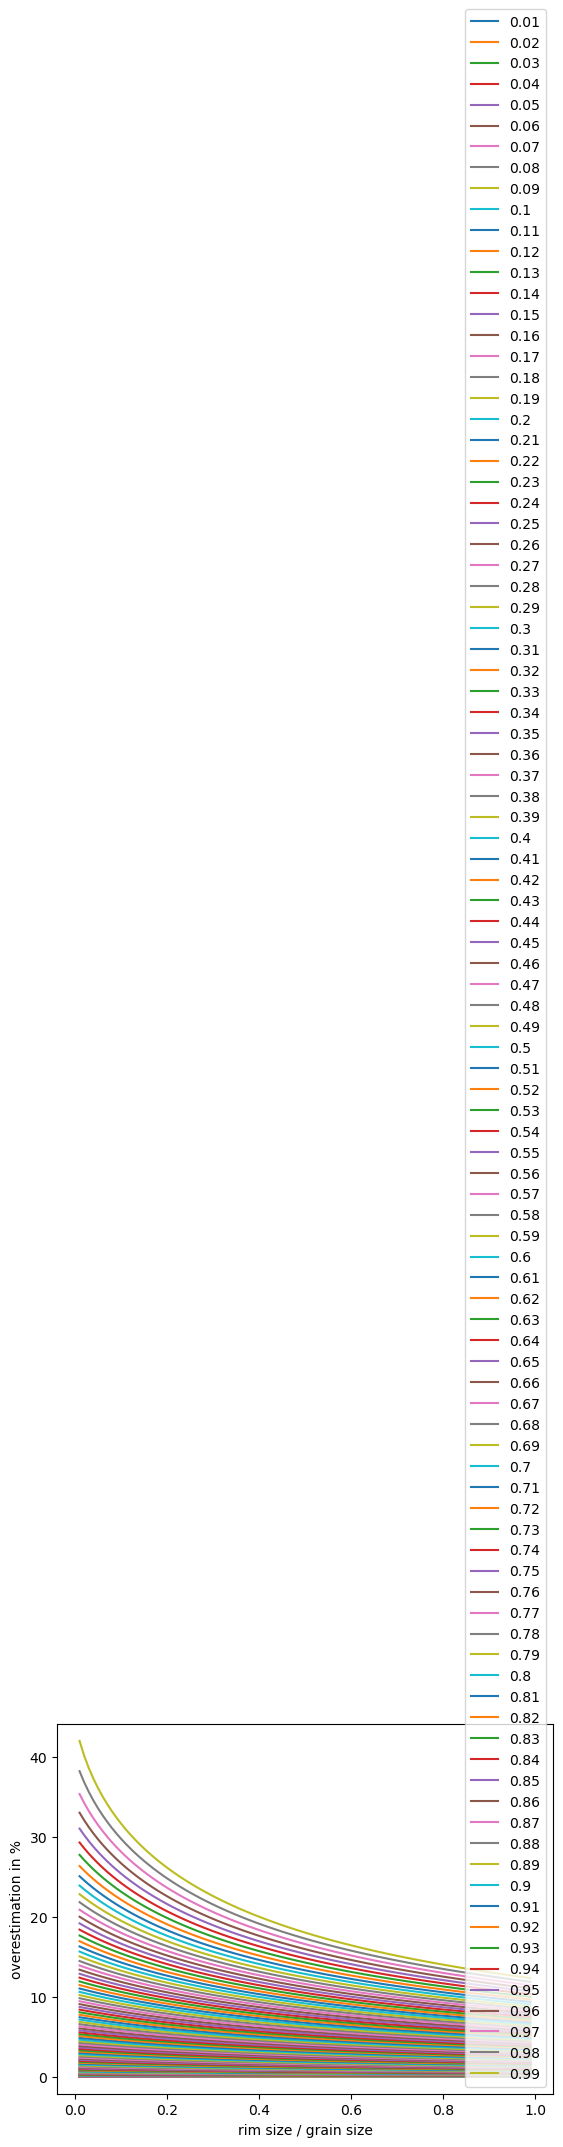

In [4]:
grain = 1.0
i_start = 0
i_stop  = 1
results = {}
steps = 100
X = []
Y = []
Z = []
for j in range(1,100,1):
	i_stop = j/100
	x_line = []
	y_line = []
	z_line = []
	results[i_stop] = {}
	for i in range(1, steps):
		rim = i/steps
		I = quad(integrand, i_start, i_stop, args=(grain, rim))
		z = I[0]/(rim*(i_stop-i_start)) * 100 - 100
		results[i_stop][rim] = z
		x_line.append(rim)
		y_line.append(i_stop)
		z_line.append(z)
	X.append(x_line)
	Y.append(y_line)
	Z.append(z_line)

	plt.plot(results[i_stop].keys(), results[i_stop].values(), label=i_stop)

X = np.array(X)
Y = np.array(Y)
Z = np.array(Z)

plt.legend(loc='lower right')
plt.xlabel('rim size / grain size')
plt.ylabel('overestimation in %')
plt.show()

In [5]:
rim_s = 0.3
p = int( rim_s*100-1 )

if (X[0][p] == rim_s): print("found selected rim_s value {}".format(rim_s))
print(p, Y[:,p])


found selected rim_s value 0.3
29 [0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1  0.11 0.12 0.13 0.14
 0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23 0.24 0.25 0.26 0.27 0.28
 0.29 0.3  0.31 0.32 0.33 0.34 0.35 0.36 0.37 0.38 0.39 0.4  0.41 0.42
 0.43 0.44 0.45 0.46 0.47 0.48 0.49 0.5  0.51 0.52 0.53 0.54 0.55 0.56
 0.57 0.58 0.59 0.6  0.61 0.62 0.63 0.64 0.65 0.66 0.67 0.68 0.69 0.7
 0.71 0.72 0.73 0.74 0.75 0.76 0.77 0.78 0.79 0.8  0.81 0.82 0.83 0.84
 0.85 0.86 0.87 0.88 0.89 0.9  0.91 0.92 0.93 0.94 0.95 0.96 0.97 0.98
 0.99]


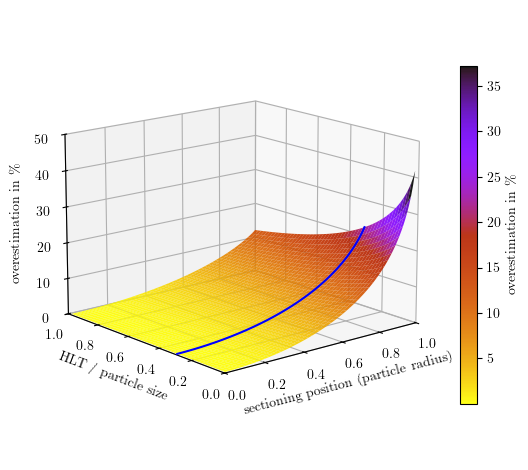

In [6]:

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Computer Modern Roman"
})

fig = plt.figure()#figsize=(12, 4)
ax = fig.add_subplot(projection='3d')

ax.invert_yaxis()
ax.view_init(elev=15, azim=-130)

# Plot a basic wireframe.
surf = ax.plot_surface(Y, X, Z, cmap=cm.gnuplot_r, antialiased=True,rasterized=False, edgecolor='none', alpha=0.9)
ax.plot3D(np.array([Y[:,p]]), np.array([X[:,p]]), np.array([Z[:,p]]), color='blue',zorder=3)

#ax.plot_wireframe(X, Y, Z, rstride=1, cstride=10)
#ax.plot_wireframe(X, Y, Z, linewidth=.5, rstride=1, cstride=10, alpha=0.7, edgecolor='royalblue')
#ax.contourf(X, Y, Z, zdir='x', offset=0, cmap='coolwarm')
#ax.contourf(X, Y, Z, zdir='y', offset=1, cmap='coolwarm')
#ax.contourf(X, Y, Z, zdir='z', offset=0, cmap='coolwarm')

ax.set(xlim=(0,1), ylim=(0,1), zlim=(0,50),
       #xlabel='limit $i$ of $\\int_{0}^{i} l_{\\mathrm{HLT}}(x) \\,dx$',
       xlabel='sectioning position (particle radius)',
       ylabel='HLT / particle size')
fig.colorbar(surf, shrink=0.75, aspect=20, pad=0.00, label='overestimation in \%')
ax.zaxis.set_rotate_label(False)  # disable automatic rotation
ax.set_zlabel('overestimation in \%', rotation=90)
ax.set_box_aspect(aspect=None, zoom=0.86)

plt.tight_layout()
plt.savefig('../sectioning_overestimation.svg')
plt.savefig('../sectioning_overestimation.pdf')
plt.show()